In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our graphs
sns.set_theme(style="darkgrid")

In [9]:
print("Scanning Data/player/ folder...")
player_files = glob.glob("Data/player/player_*_info.csv")

if not player_files:
    print("No player files found! Make sure you ran the data gatherer first.")
else:
    # Read every file and combine them
    df_list = [pd.read_csv(f) for f in player_files]
    players_df = pd.concat(df_list, ignore_index=True)
    
    print(f"Successfully loaded {len(players_df)} players into the dataset.")
    
    # Display the first few rows just to verify
    display(players_df.head())

Scanning Data/player/ folder...
Successfully loaded 500 players into the dataset.


,puuid,rank
0,-ABRPK_6Z2ezIw-i-PXERrF_nrElE-s2gy3bxXcgjw-bgw...,SILVER II
1,-DD2KYrrk8XS0y-ma6ybUzfvgjGCMVlmes7TXlYgSmjLKP...,SILVER IV
2,-HHyc_i5RvjSkn6YWGXK0Dpx20hQ5G_53reVQYap-9nA4t...,BRONZE I
3,-ISJYKgIjJ5-bWLAen6zwjHcyGNFweT8umPdwYrP2_RAD6...,GOLD IV
4,-nPLWMXOC7DrfHQXlS-GA5gTrWCzGbrqaz7ztdgGwRKz2W...,BRONZE II


## Rank plot

C:\Users\isakw\AppData\Local\Temp\ipykernel_29636\2562477005.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


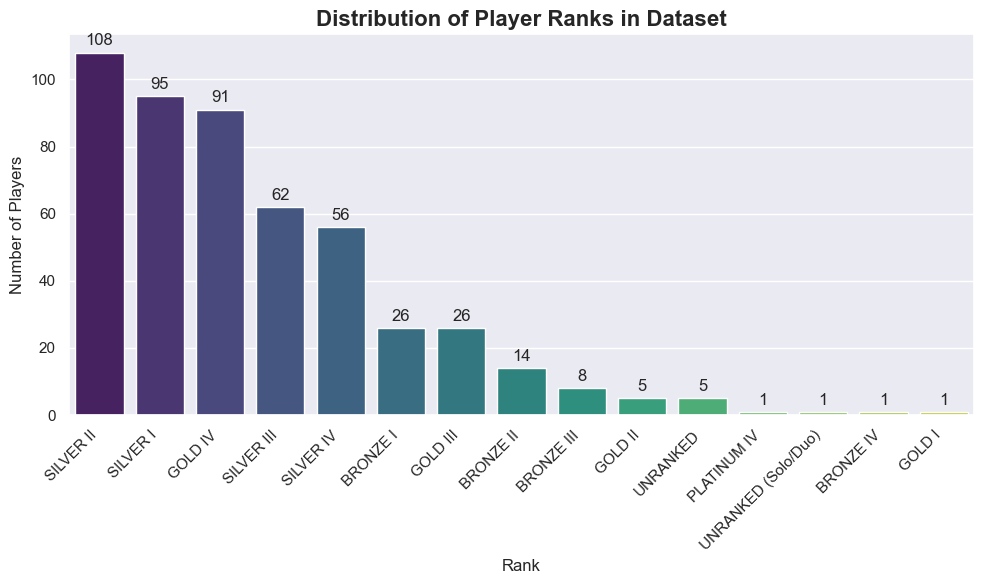

In [12]:
# Count the occurrences of each rank
rank_counts = players_df['rank'].value_counts().reset_index()
rank_counts.columns = ['Rank', 'Player Count']

# Create the figure
plt.figure(figsize=(10, 6))

# Build the bar chart
ax = sns.barplot(
    data=rank_counts, 
    x='Rank', 
    y='Player Count', 
    palette="viridis" # A nice color palette that looks great on dark and light themes
)

# Add titles and labels
plt.title("Distribution of Player Ranks in Dataset", fontsize=16, fontweight='bold')
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

# Rotate the x-axis labels so they don't overlap (crucial for long rank names!)
plt.xticks(rotation=45, ha='right')

# Add the exact count numbers on top of each bar
for i in ax.containers:
    ax.bar_label(i, padding=3)

# Adjust layout to fit the rotated labels and show the plot
plt.tight_layout()
plt.show()